# Exploratory Data Analysis (EDA)

In this notebook, we'll explore the marketing campaign data to understand distributions, relationships, and campaign performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
sns.set_style('whitegrid')

df = pd.read_csv('../data/feature_engineered/feature_engineered_dataset.csv')
df.head()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,...,Customer_Segment,Date,Brand,Profit_Flag,Channel_Email,Channel_Facebook,Channel_Google,Channel_Instagram,Channel_WhatsApp,Channel_YouTube
0,NY-CMP-1000,Social Media,College Students,21.0,57804.0,6156.0,3616.0,2355.0,1867515.0,208.725,...,College Students,29-04-2025,Nykaa,1,0,0,0,0,1,1
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18.0,91801.0,3321.0,1971.0,1357.0,1046247.0,180.830,...,College Students,06-04-2025,Nykaa,1,0,0,0,0,0,1
2,NY-CMP-1002,Influencer,Youth,23.0,15536.0,2182.0,952.0,755.0,197055.0,90.600,...,College Students,14-01-2025,Nykaa,1,0,0,1,0,1,1
3,NY-CMP-1003,Email,Working Women,18.0,88114.0,8413.0,2231.0,947.0,376906.0,249.070,...,Youth,04-06-2025,Nykaa,1,0,1,0,1,0,1
4,NY-CMP-1004,Paid Ads,College Students,10.0,96871.0,3743.0,2060.0,1258.0,518296.0,228.600,...,Tier 2 City Customers,29-12-2024,Nykaa,1,0,1,0,1,0,0


In [2]:
# Summary statistics
df.describe()

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score,Profit_Flag,Channel_Email,Channel_Facebook,Channel_Google,Channel_Instagram,Channel_WhatsApp,Channel_YouTube
count,166665.000000,166665.000000,166665.000000,166665.000000,166665.000000,1.666650e+05,166665.000000,166665.000000,166665.000000,166665.000000,166665.000000,166665.000000,166665.000000,166665.000000,166665.000000,166665.000000
mean,17.464183,55070.942483,4646.634590,1852.937011,1016.330177,5.061062e+05,368.599021,6058.905493,13.756366,0.999934,0.366784,0.316887,0.316989,0.317343,0.316347,0.316689
std,7.312826,25313.049988,3102.538446,1397.723107,838.602514,4.764853e+05,524.652180,13748.551572,6.172954,0.008124,0.481928,0.465264,0.465305,0.465444,0.465052,0.465186
min,5.000000,10001.000000,202.000000,48.000000,17.000000,3.895000e+03,8.180000,-0.740989,2.560000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,11.000000,33783.000000,2185.000000,809.000000,417.000000,1.854360e+05,111.100000,484.044643,8.650000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,17.000000,55113.000000,3908.000000,1476.000000,775.000000,3.588720e+05,208.725000,1746.657296,13.590000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,24.000000,76427.000000,6510.000000,2525.000000,1357.000000,6.595050e+05,410.920000,5611.267432,18.530000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,30.000000,100000.000000,14944.000000,8876.000000,6686.000000,4.579910e+06,15473.160000,494114.403423,30.990000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 1. Brand Performance
Let's see which brand generates the most revenue and profit.

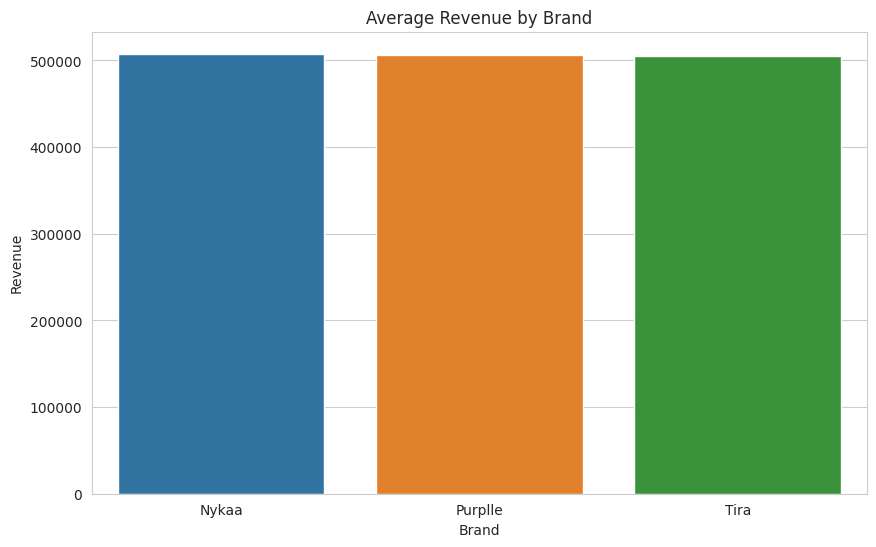

In [3]:
brand_perf = df.groupby('Brand')[['Revenue', 'Acquisition_Cost', 'Profit_Flag']].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=brand_perf, x='Brand', y='Revenue', hue='Brand')
plt.title('Average Revenue by Brand')
plt.show()

## 2. Correlation Analysis
What factors are most correlated with Revenue?

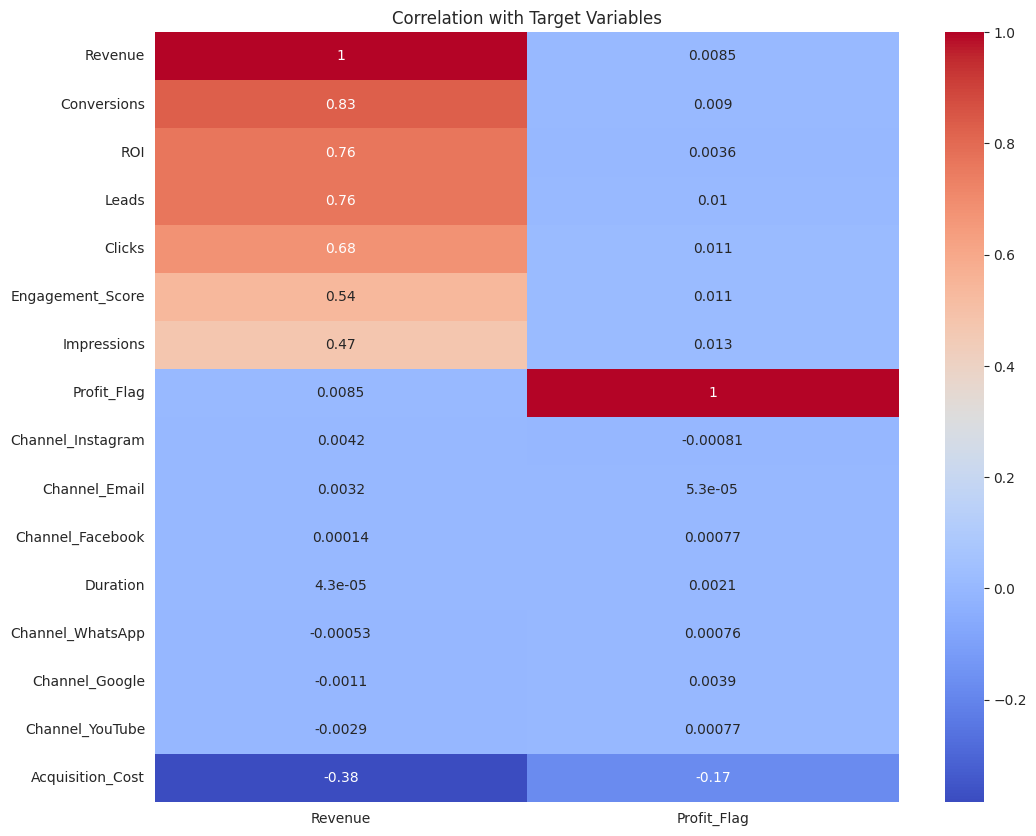

In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr[['Revenue', 'Profit_Flag']].sort_values(by='Revenue', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation with Target Variables')
plt.show()

## 3. Campaign Type Analysis

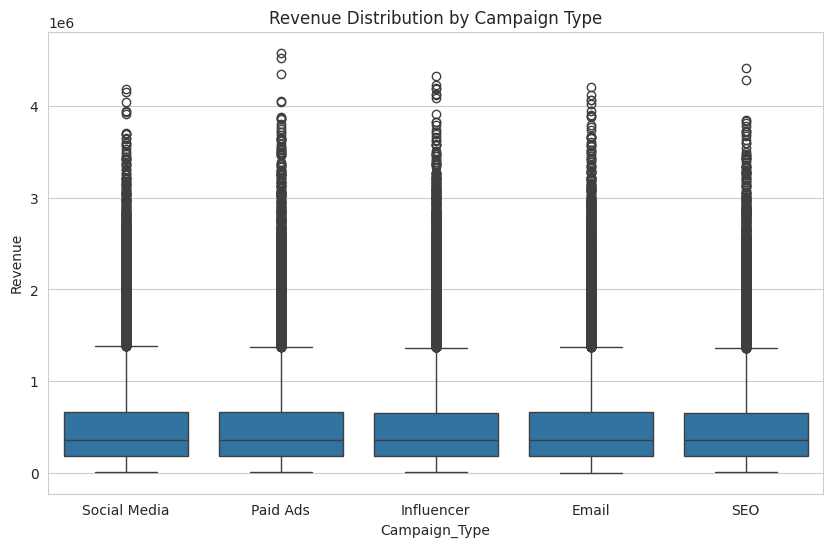

In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Campaign_Type', y='Revenue')
plt.title('Revenue Distribution by Campaign Type')
plt.show()